In [170]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import matplotlib as mpl
import seaborn as sb
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'


# General utils
from tqdm import tqdm
from os import path

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Keeping the relative feature sets

In [3]:
pickle_dirs = '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Dataset pickles/'

all_df = pd.read_pickle(path.join(pickle_dirs,'all_df.pkl'))
R1 = all_df[all_df['Region'] == 'R1']
R2 = all_df[all_df['Region'] == 'R2']

divisions = pd.read_pickle(path.join(pickle_dirs,'divisions.pkl'))
divisions_12h = pd.read_pickle(path.join(pickle_dirs,'divisions_12h.pkl'))
divisions_24h = pd.read_pickle(path.join(pickle_dirs,'divisions_24h.pkl'))
divisions_36h = pd.read_pickle(path.join(pickle_dirs,'divisions_36h.pkl'))
divisions_48h = pd.read_pickle(path.join(pickle_dirs,'divisions_48h.pkl'))
divisions_60h = pd.read_pickle(path.join(pickle_dirs,'divisions_60h.pkl'))
divisions_72h = pd.read_pickle(path.join(pickle_dirs,'divisions_72h.pkl'))

feature_names = divisions.columns

In [3]:
# Filter out the un-needed features by category

category_keywords_2drop = ['adjac','diff','rate relative','time','Meta','FUCCI']
filter_out = np.any(np.array([feature_names.get_level_values(1).str.contains(kwd) for kwd in category_keywords_2drop]),axis=0)

feature2keep = (feature_names.get_level_values(0) == 'LineageID')
feature2keep = feature2keep | (feature_names.get_level_values(0) == 'Num daughter differentiated')
feature2keep = feature2keep | (feature_names.get_level_values(0) == 'Division')
feature2keep = feature2keep | (feature_names.get_level_values(0) == 'Mother')
feature2keep = feature2keep | (feature_names.get_level_values(0) == 'Daughter a')
feature2keep = feature2keep | (feature_names.get_level_values(0) == 'Daughter b')
feature2keep = feature2keep | (feature_names.get_level_values(0) == 'Cell type')
filter_out = filter_out & ~feature2keep

print(filter_out.sum())

570


In [62]:
# Add to the filter list, specific hand-picked features

manual_features2drop_keywords = ['cell coords','pixel','Time to divide','Time to differentiate','Z','Height to BM',
                                'Manual cell volume','growth rate']
filter_out = filter_out | np.any(np.array([feature_names.get_level_values(0).str.contains(kwd) for kwd in manual_features2drop_keywords]),axis=0)

# Exclude any that includes 'smooth' without 'rate'
has_smooth = np.array([feature_names.get_level_values(0).str.contains('smoothed')]).squeeze()
has_rate = np.array([feature_names.get_level_values(0).str.contains('rate')]).squeeze()
has_smooth_no_rate = has_smooth & ~has_rate
filter_out = filter_out | has_smooth_no_rate

print(filter_out.sum())

597


In [63]:
f2keep = feature_names[~filter_out]

# print(f2keep.get_level_values(0).values)
f2keep[f2keep.get_level_values(0) == 'Cell type']
f2keep[f2keep.get_level_values(0) == 'Division']


MultiIndex([('Division', 'Meta')],
           )

In [76]:
basals = all_df[all_df['Cell type','Meta'] == 'Basal']
basals = basals[~basals['Border','Meta']]

basals[f2keep].isna().sum().sort_values(ascending=False).iloc[0:50]

# 'Nuclear volume exponential growth rate' in f2keep.get_level_values(0)

Num daughter differentiated                     Meta                                     7022
Daughter b                                      Meta                                     4782
Daughter a                                      Meta                                     4782
Mother                                          Meta                                     2251
Num neighbor division 1 frame prior             Measurement topology                      546
Num neighbor delamination 1 frame prior         Measurement topology                      546
Relative Cell volume                            Measurement cell shape relative             8
Relative Apical area                            Measurement cell shape relative             8
Relative Collagen coherence                     Measurement collagen relative               8
Relative Collagen orientation                   Measurement collagen relative               8
Relative Cell height                            Measurement 

In [84]:
divisions[f2keep].isnull().sum()


Nuclear volume                           Measurement nuclear shape      0
Nuclear solidity                         Measurement nuclear shape      0
Nuclear height                           Measurement nuclear shape      0
Cell volume                              Measurement cell shape         0
Axial component                          Measurement cell shape         0
                                                                     ... 
Min distance to neighbors                Measurement cell position      0
Std distance to neighbors                Measurement cell position      0
Num neighbor division 1 frame prior      Measurement topology          69
Num neighbor delamination 1 frame prior  Measurement topology          69
Num daughter differentiated              Meta                         365
Length: 62, dtype: int64

In [86]:
# Check for NAs

basals[f2keep].isnull().sum(axis=0).sort_values(ascending=False).head(20)


Num daughter differentiated              Meta                            7022
Daughter a                               Meta                            4782
Daughter b                               Meta                            4782
Mother                                   Meta                            2251
Num neighbor division 1 frame prior      Measurement topology             546
Num neighbor delamination 1 frame prior  Measurement topology             546
Std distance to neighbors                Measurement cell position          7
Min distance to neighbors                Measurement cell position          7
Max distance to neighbors                Measurement cell position          7
Median distance to neighbors             Measurement cell position          7
Mean distance to neighbors               Measurement cell position          7
Num basal neighbors                      Measurement topology               7
Cell type                                Meta                   

In [79]:

all_df_filt = all_df[f2keep]
R1_filt = R1[f2keep]
R2_filt = R2[f2keep]

div = divisions[f2keep]
div12 = divisions_12h[f2keep]
div24 = divisions_24h[f2keep]
div36 = divisions_36h[f2keep]
div48 = divisions_48h[f2keep]
div60 = divisions_60h[f2keep]
div72 = divisions_72h[f2keep]


In [21]:
print(div.columns.get_level_values(1).unique())

Index(['Measurement nuclear shape', 'Measurement cell shape',
       'Measurement cell position', 'Measurement H2B', 'Measurement collagen',
       'Measurement tissue geometry', 'Measurement cell geometry',
       'Measurement nuclear geometry', 'Meta', 'Measurement shcoeff_PCA', '',
       'Measurement nuclear shape rate', 'Measurement cell shape rate',
       'Measurement H2B rate', 'Measurement collagen rate',
       'Measurement topology', 'Measurement nuclear shape relative',
       'Measurement cell shape relative', 'Measurement H2B relative',
       'Measurement collagen relative', 'Measurement tissue geometry relative',
       'Measurement cell geometry relative',
       'Measurement nuclear geometry relative',
       'Measurement shcoeff_PCA relative'],
      dtype='object')


In [22]:

dataset_savedir = '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Annotability datasets'

all_df_filt.to_pickle(path.join(dataset_savedir,'not_cell_cycle_aligned/With relative features/both_regions_filtered.pkl'))
R1_filt.to_pickle(path.join(dataset_savedir,'not_cell_cycle_aligned/With relative features/R1_filtered.pkl'))
R2_filt.to_pickle(path.join(dataset_savedir,'not_cell_cycle_aligned/With relative features/R2_filtered.pkl'))

div.to_pickle(path.join(dataset_savedir,'cell_cycle_aligned/With relative features/divisions_feature_filtered.pkl'))
div12.to_pickle(path.join(dataset_savedir,'cell_cycle_aligned/With relative features/divisions_12h_feature_filtered.pkl'))
div24.to_pickle(path.join(dataset_savedir,'cell_cycle_aligned/With relative features/divisions_24h_feature_filtered.pkl'))
div36.to_pickle(path.join(dataset_savedir,'cell_cycle_aligned/With relative features/divisions_36h_feature_filtered.pkl'))
div48.to_pickle(path.join(dataset_savedir,'cell_cycle_aligned/With relative features/divisions_48h_feature_filtered.pkl'))
div60.to_pickle(path.join(dataset_savedir,'cell_cycle_aligned/With relative features/divisions_60h_feature_filtered.pkl'))
div72.to_pickle(path.join(dataset_savedir,'cell_cycle_aligned/With relative features/divisions_72h_feature_filtered.pkl'))


# Further filter out the relative features

In [82]:
# Add to the filter list, specific hand-picked features

# Filter out the un-needed features by category
category_keywords_2drop = ['relative']
filter_out = filter_out | np.any(np.array([feature_names.get_level_values(1).str.contains(kwd) for kwd in category_keywords_2drop]),axis=0)
print(filter_out.sum())


641


In [83]:
f2keep = feature_names[~filter_out]

print(f2keep.get_level_values(0).values)


['Nuclear volume' 'Nuclear solidity' 'Nuclear height' 'Cell volume'
 'Axial component' 'Planar component 1' 'Planar component 2' 'Axial angle'
 'Planar angle' 'Y' 'X' 'Nuclear centeredness' 'Mean H2B intensity'
 'Total H2B intensity' 'Apical area' 'Basal area' 'Basal orientation'
 'Basal eccentricity' 'Middle area' 'Cell height' 'Collagen orientation'
 'Collagen coherence' 'Collagen alignment to basal footprint'
 'Collagen intensity' 'NC ratio' 'BM height' 'Mean curvature 2um'
 'Gaussian curvature 2um' 'Mean curvature 5um' 'Gaussian curvature 5um'
 'Mean curvature 10um' 'Gaussian curvature 10um' 'Mean curvature 15um'
 'Gaussian curvature 15um' 'Cell surface area' 'Nuclear surface area'
 'Distance to closest macrophage' 'LineageID' 'Division' 'Mother'
 'Daughter a' 'Daughter b' 'Cell type' 'shcoeff_PC0' 'shcoeff_PC1'
 'shcoeff_PC2' 'shcoeff_PC3' 'shcoeff_PC4' 'shcoeff_PC5' 'shcoeff_PC6'
 'shcoeff_PC7' 'shcoeff_PC8' 'Region' 'Num basal neighbors'
 'Mean distance to neighbors' 'Median dis

In [25]:

all_df_filt_no_rel = all_df[f2keep]
R1_filt_no_rel = R1[f2keep]
R2_filt_no_rel = R2[f2keep]

div_no_rel = divisions[f2keep]
div12_no_rel = divisions_12h[f2keep]
div24_no_rel = divisions_24h[f2keep]
div36_no_rel = divisions_36h[f2keep]
div48_no_rel = divisions_48h[f2keep]
div60_no_rel = divisions_60h[f2keep]
div72_no_rel = divisions_72h[f2keep]


In [26]:
print(div_no_rel.columns.get_level_values(1).unique())

Index(['Measurement nuclear shape', 'Measurement cell shape',
       'Measurement cell position', 'Measurement H2B', 'Measurement collagen',
       'Measurement tissue geometry', 'Measurement cell geometry',
       'Measurement nuclear geometry', 'Meta', 'Measurement shcoeff_PCA', '',
       'Measurement nuclear shape rate', 'Measurement cell shape rate',
       'Measurement H2B rate', 'Measurement collagen rate',
       'Measurement topology'],
      dtype='object')


In [27]:
dataset_savedir = '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Annotability datasets'

all_df_filt_no_rel.to_pickle(path.join(dataset_savedir,'not_cell_cycle_aligned/Without relative features/both_regions_filtered.pkl'))
R1_filt_no_rel.to_pickle(path.join(dataset_savedir,'not_cell_cycle_aligned/Without relative features/R1_filtered.pkl'))
R2_filt_no_rel.to_pickle(path.join(dataset_savedir,'not_cell_cycle_aligned/Without relative features/R2_filtered.pkl'))

div_no_rel.to_pickle(path.join(dataset_savedir,'cell_cycle_aligned/Without relative features/divisions_feature_filtered.pkl'))
div12_no_rel.to_pickle(path.join(dataset_savedir,'cell_cycle_aligned/Without relative features/divisions_12h_feature_filtered.pkl'))
div24_no_rel.to_pickle(path.join(dataset_savedir,'cell_cycle_aligned/Without relative features/divisions_24h_feature_filtered.pkl'))
div36_no_rel.to_pickle(path.join(dataset_savedir,'cell_cycle_aligned/Without relative features/divisions_36h_feature_filtered.pkl'))
div48_no_rel.to_pickle(path.join(dataset_savedir,'cell_cycle_aligned/Without relative features/divisions_48h_feature_filtered.pkl'))
div60_no_rel.to_pickle(path.join(dataset_savedir,'cell_cycle_aligned/Without relative features/divisions_60h_feature_filtered.pkl'))
div72_no_rel.to_pickle(path.join(dataset_savedir,'cell_cycle_aligned/Without relative features/divisions_72h_feature_filtered.pkl'))


In [205]:
divisions['Concavity','Meta'] = \
    divisions['Mean curvature 5um','Measurement tissue geometry'] > 0

divisions['Concavity_bin','Meta'] = \
    pd.cut(divisions['Mean curvature 5um','Measurement tissue geometry'],[-1,-.2,.2,1])


from sklearn import metrics

_df = divisions[[['Region',''],
              ['Concavity','Meta'],
              ['Num daughter differentiated','Meta'],
              ['At least one daughter differentiated','Meta'],
              ['Concavity_bin','Meta'],
             ]]
# _df = _df[ _df['Region'] == 'R2']
_df = _df.dropna().droplevel(axis=1,level=1)

# plt.savefig('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Morphology differences/mother_concavity_heatmap.eps')


Frame  TrackID
0      R1_2       2.0
       R1_28      2.0
       R1_38      1.0
       R1_53      1.0
       R1_90      2.0
                 ... 
8      R2_788     2.0
       R2_813     0.0
9      R2_619     2.0
10     R2_25      2.0
       R2_1063    2.0
Name: Num daughter differentiated, Length: 303, dtype: float64

/var/folders/zp/5k1kvm9j0t19cvq8h628kr8h0000gn/T/ipykernel_3572/4020549305.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _,x in _df.groupby(['Concavity_bin','Num daughter differentiated'])}


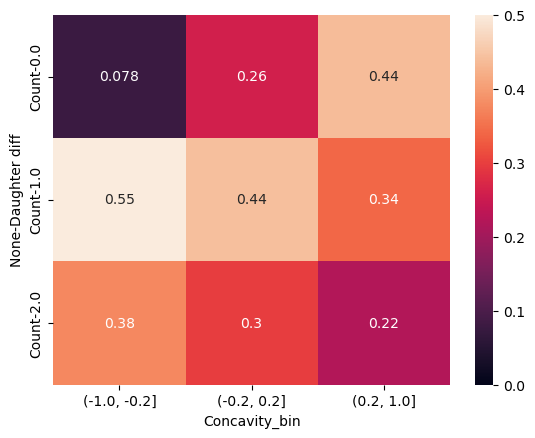

In [207]:

contingency_table = {(x.iloc[0]['Concavity_bin'],x.iloc[0]['Num daughter differentiated']):len(x) 
    for _,x in _df.groupby(['Concavity_bin','Num daughter differentiated'])}

contingency_table = pd.DataFrame(contingency_table.values(),
            index=pd.MultiIndex.from_tuples(contingency_table.keys(),name=['Concavity_bin','Daughter diff']),
            columns=['Count']).unstack().T

contingency_table / contingency_table.sum(axis=0)

sb.heatmap(contingency_table / contingency_table.sum(axis=0),annot=True,
          vmin = 0,vmax=0.5)
# sb.heatmap(contingency_table / contingency_table.sum(axis=0),annot=True)

plt.savefig('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Morphology differences/mother_concavity_daughter_fate_contingency_table.svg')

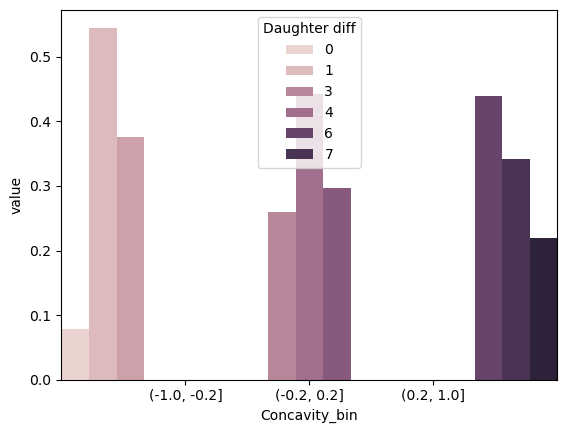

In [208]:
C = contingency_table / contingency_table.sum(axis=0)


# reset_index()

sb.barplot( C.melt().reset_index(names='Daughter diff'),
          x='Concavity_bin',
          hue='Daughter diff',
          y='value',
          width=2)
plt.xlim([-1,3])

plt.savefig('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Morphology differences/mother_concavity_daughter_fate_barplot.svg')


In [209]:
contingency_table.sum(axis=0)


Concavity_bin
(-1.0, -0.2]     77
(-0.2, 0.2]     185
(0.2, 1.0]       41
dtype: int64